Password1
# GNN Model Extraction: Attack 2 vs Attack 4
This notebook specifically compares two distinct attack scenarios from the taxonomy to demonstrate how different knowledge levels (Structure and Shadow datasets) impact the success of model extraction.

In [1]:
import torch as th
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from bank_data_loader import load_bank_data
from bank_attacks import run_attack
from bank_visualizer import plot_bank_network, plot_extracted_network
from synthetic_generator import generate_synthetic_bank_data
import os

# Configuration
CSV_PATH = "bank_transaction_data_large.csv"
ATTACK_RATIO = 0.05

if not os.path.exists(CSV_PATH):
    print("Generating dataset...")
    generate_synthetic_bank_data(num_records=100000, fraud_rate=0.01, output_file=CSV_PATH)
else:
    print("Dataset already exists.")

Dataset already exists.


/home/lonewolf/anaconda3/envs/dl/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Execution of Attack 2
**Profile**: Unknown Attributes, Known Structure, Unknown Shadow.
The adversary knows exactly who transacts with whom, but has no idea what the node features are and no proxy dataset.

In [2]:
print("Executing Attack 2...")
model_2, g_2, feat_2, fid_2 = run_attack(
    2, CSV_PATH, ATTACK_RATIO, sampling_strategy="random"
)
print(f"Attack 2 Fidelity: {fid_2:.4f}")

Executing Attack 2...
Training Target Model for Attack 2...
Target Model Accuracy: 0.8401
Executing Attack 2 ({'attr': 'unknown', 'struct': 'known', 'shadow': 'unknown'})
Attack 2 Fidelity: 0.9813
Attack 2 Fidelity: 0.9813


## 2. Execution of Attack 4
**Profile**: Partial Attributes, Partial Structure, Known Shadow.
The adversary has approximate features, a sampled version of the graph, and a supplementary shadow dataset to pre-train the surrogate.

In [3]:
print("Executing Attack 4...")
model_4, g_4, feat_4, fid_4 = run_attack(
    4, CSV_PATH, ATTACK_RATIO, sampling_strategy="random"
)
print(f"Attack 4 Fidelity: {fid_4:.4f}")

Executing Attack 4...
Training Target Model for Attack 4...
Target Model Accuracy: 0.9798
Executing Attack 4 ({'attr': 'partial', 'struct': 'partial', 'shadow': 'known'})
Pre-training surrogate on Shadow Dataset...
Attack 4 Fidelity: 0.9798
Attack 4 Fidelity: 0.9798


## 3. Comparison & Visualization
Comparing the results and the structural views available to the adversary.

     Attack Structure Knowledge Shadow Dataset  Fidelity
0  Attack 2               Known        Unknown   0.98135
1  Attack 4             Partial          Known   0.97980


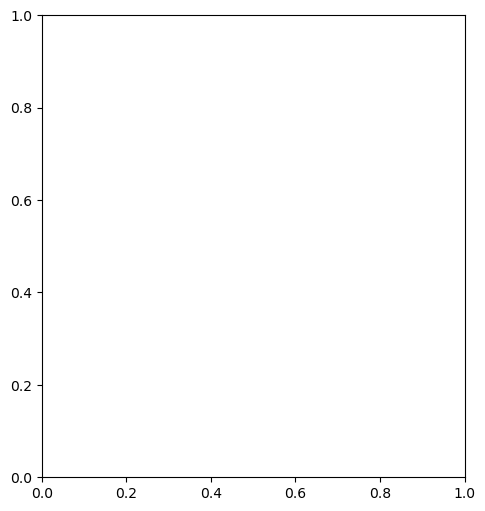

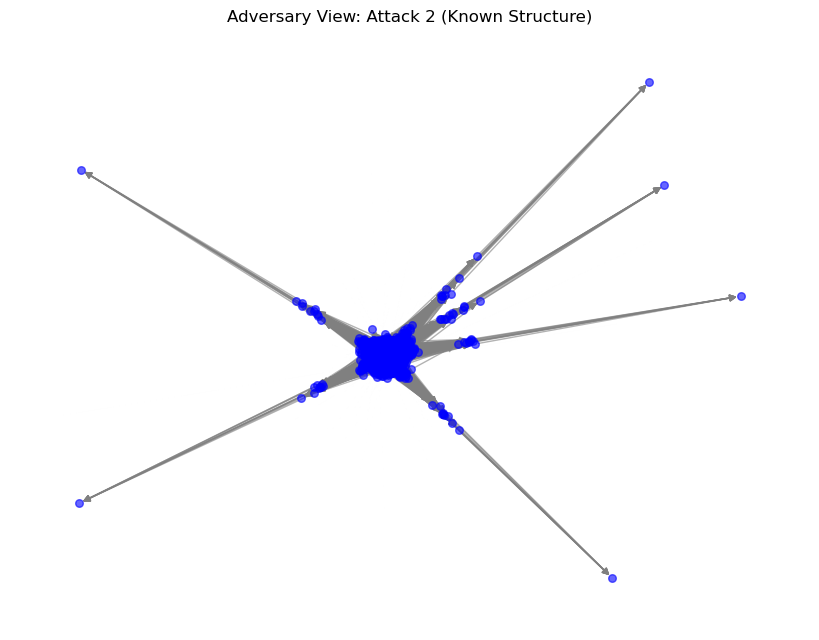

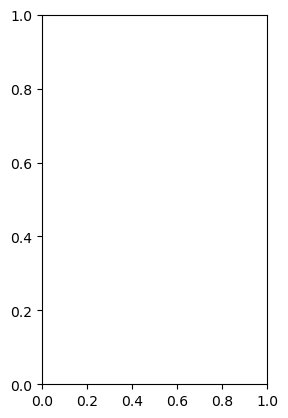

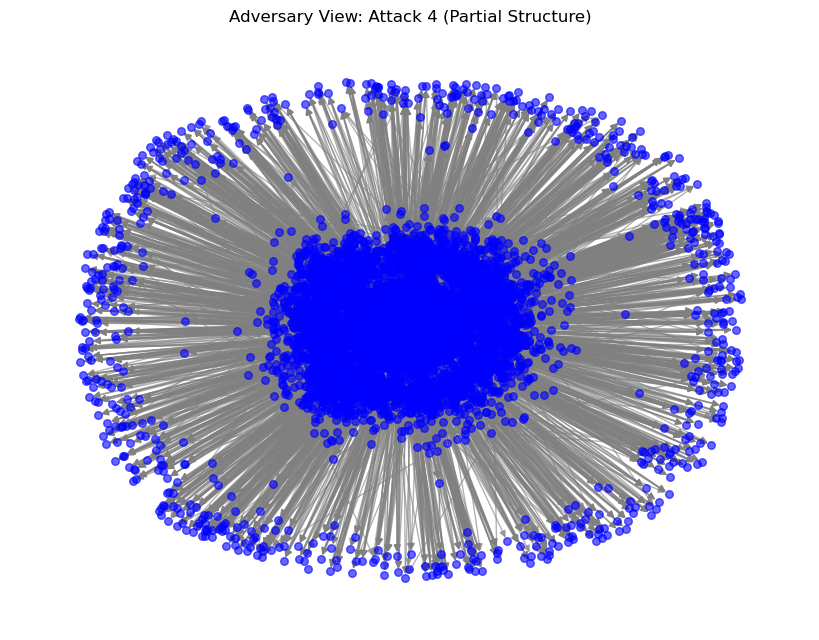

<Figure size 640x480 with 0 Axes>

In [4]:
# Comparison Table
comparison_df = pd.DataFrame({
    "Attack": ["Attack 2", "Attack 4"],
    "Structure Knowledge": ["Known", "Partial"],
    "Shadow Dataset": ["Unknown", "Known"],
    "Fidelity": [fid_2, fid_4]
})
print(comparison_df)

# Visualizing the views
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_extracted_network(g_2, title="Adversary View: Attack 2 (Known Structure)")

plt.subplot(1, 2, 2)
plot_extracted_network(g_4, title="Adversary View: Attack 4 (Partial Structure)")

plt.tight_layout()
plt.show()

### Analysis
Observe how Attack 4 often achieves higher fidelity despite having "Partial" structure, because the **Shadow Dataset** provides a strong prior for the surrogate model's weights, whereas Attack 2 relies purely on querying the target model with random features.